# Analysis 7 — Which colours of light tell flooring types apart?
### A statistical (ANOVA) look at NIR spectra of hardwood vs vinyl flooring

---

### The big picture (read this first)

We scanned 134 pieces of flooring with a **near-infrared (NIR) spectrometer**. The device shines
light at 249 slightly different "colours" (wavelengths, from 1454 to 2446 nm — just past what the
eye can see) and measures how much of each colour the material absorbs. Each scan is therefore a
list of 249 numbers — a *fingerprint* of the material's chemistry.

Different materials absorb different colours because their molecules vibrate at characteristic
frequencies. Vinyl (a plastic) and wood (cellulose + lignin) have very different chemistry, so we'd
expect their fingerprints to differ — but **at which specific colours?**

> **The question this notebook answers:** *For each of the 249 wavelengths, is the amount of light
> absorbed genuinely different between the flooring groups — or could the difference just be random
> noise?* The wavelengths that pass this test are the ones a real instrument should pay attention to.

We ask it three times, for three ways of grouping the samples:

| # | Grouping | Why we care |
|---|----------|-------------|
| 1 | **Vinyl vs Hardwood** (2 groups) | The headline task: plastic vs real wood |
| 2 | **9 classes** (3 vinyl wear-layers + 6 wood species) | The full, fine-grained problem |
| 3 | **6 wood species only** | The hardest part — telling oak from pine, etc. |

The tool for "is this difference real or just noise?" across several groups is called **ANOVA**.


### A 2-minute statistics primer (no background needed)

We'll use three ideas. Here they are in plain English:

**1. ANOVA (Analysis of Variance) → the F-statistic.**
Imagine the absorbance values at one wavelength, split into groups (e.g. vinyl scans vs wood scans).
ANOVA compares two things:
- how far apart the *group averages* are (signal), versus
- how spread out the values are *within* each group (noise).

The ratio is the **F-statistic**:

$$F = \frac{\text{variation between groups}}{\text{variation within groups}}$$

- **F near 1** → groups overlap; this wavelength can't tell them apart.
- **F large (10s, 100s, 1000s)** → group averages are far apart relative to the noise; this
  wavelength is a strong discriminator. *Bigger F = more useful colour.*

**2. The p-value → "could this be a fluke?"**
The p-value is the probability of seeing a difference this big *if there were really no difference*
(pure chance). Small p = "a fluke is very unlikely, the difference looks real." The usual cutoff is
p < 0.05.

**3. Bonferroni correction → being honest about 249 tests at once.**
If you run 249 separate tests at p < 0.05, then ~5% (about 12 wavelengths) would look "significant"
**by chance alone**. To avoid being fooled, we tighten the cutoff: divide 0.05 by the number of
tests (249), giving p < 0.0002. A wavelength must clear this stricter bar to count as genuinely
significant. This is conservative on purpose.

That's the whole toolkit. Everything below is applying these three ideas 249 times and reading the
results.


## Step 0 · Setup

Standard scientific-Python libraries. `scipy.stats.f_oneway` does the ANOVA; `statsmodels` provides
the Tukey post-hoc test we use later. `ALPHA = 0.05` is our base significance level (before the
Bonferroni tightening).

In [1]:
# --- Libraries -------------------------------------------------------------
import pandas as pd                       # tables / reading the Excel file
import numpy as np                        # fast numeric arrays + math
import matplotlib.pyplot as plt           # plotting
from scipy.signal import savgol_filter    # Savitzky-Golay smoothing/derivative
from scipy import stats                   # stats.f_oneway = the ANOVA test
from statsmodels.stats.multicomp import pairwise_tukeyhsd  # Tukey post-hoc test

# A consistent, clean look for every figure in the notebook
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11
})

ALPHA = 0.05   # base significance level (we tighten this with Bonferroni later)

## Step 1 · Load the scans and clean them up

We read the spreadsheet (one sheet of spectra, one of labels), parse each sample's description into
a flooring **type** and either a **wear-layer** (vinyl) or **species** (wood), then apply the two
standard preprocessing steps every notebook in this project uses:

- **SNV (Standard Normal Variate)** — removes overall brightness differences between scans, so we
  compare *shape*, not how close the probe was held.
- **Savitzky-Golay 1st derivative** — flattens slow baseline drift and sharpens the peaks, so real
  absorption features stand out.

After this, `X` is a 134 × 249 table: one row per scan, one column per wavelength.

In [2]:
# --- Read the two sheets of the export ------------------------------------
FILE = '2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx'
spec_df = pd.read_excel(FILE, sheet_name=1)   # sheet 1: the actual spectra
meta_df = pd.read_excel(FILE, sheet_name=0)   # sheet 0: labels / descriptions

# The wavelength axis (249 values) and the IDs of every scan column
wavelengths = spec_df['Wavelength (nm)'].values
spec_cols = [c for c in spec_df.columns if c != 'Wavelength (nm)']
# Map each scan ID -> its human description, e.g. "Vinyl, BrandX, wl 12, grey"
meta_dict = dict(zip(meta_df['Spectrum ID'], meta_df['Measurement Description']))


def parse_desc(d):
    """Turn a free-text description into structured fields (type + wear-layer/species).
    Returns None for calibration/reference scans we want to skip."""
    d = d.strip()
    if d.lower().startswith('water') or d.lower().startswith('test'):
        return None                                   # skip reference scans
    parts = [p.strip() for p in d.split(',')]          # split on commas
    if parts[0].lower() == 'vinyl':                    # --- a vinyl (LVP) scan
        wl = None
        for p in parts[2:]:                            # find the "wl N" wear-layer token
            if p.lower().startswith('wl '):
                try: wl = float(p.split()[1])
                except: pass
        return {'type': 'LVP', 'wear_layer': wl, 'desc': d}
    elif parts[0].lower() == 'lumber':                 # --- a real-wood scan
        return {'type': 'Hardwood',
                'species': (parts[1].strip() if len(parts) > 1 else 'unknown'), 'desc': d}
    return None

# Build one row per usable scan, carrying its parsed labels + raw spectrum
rows = []
for sid in spec_cols:
    desc = meta_dict.get(sid)
    if not desc: continue
    parsed = parse_desc(str(desc))
    if not parsed: continue
    rows.append({'id': sid, **parsed, 'spectrum': spec_df[sid].values})

df = pd.DataFrame([{k: v for k, v in r.items() if k != 'spectrum'} for r in rows])  # labels table
spectra = np.array([r['spectrum'] for r in rows])     # numeric matrix: scans x wavelengths


# --- Preprocessing: two standard NIR clean-up steps -----------------------
def snv(X):
    """Standard Normal Variate: per-scan, subtract its mean and divide by its
    std. Cancels overall brightness differences so we compare spectral *shape*."""
    return (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

def sg1(X, window=11, polyorder=2):
    """Savitzky-Golay 1st derivative: smooths, then takes the slope. Removes slow
    baseline drift and turns broad humps into sharp, easy-to-locate features."""
    return savgol_filter(X, window_length=window, polyorder=polyorder, deriv=1, axis=1)

X = sg1(snv(spectra))    # final clean matrix: 134 scans x 249 wavelengths
n_wl = X.shape[1]
print(f'{len(df)} scans, {n_wl} wavelengths ({wavelengths.min():.0f}-{wavelengths.max():.0f} nm)')

134 scans, 249 wavelengths (1454-2446 nm)


Now we build the three **grouping schemes** (the "labels") we'll test, and note the three
**diagnostic bands** chemists already associate with these materials. Keep these three wavelength
ranges in mind — a big part of the analysis is checking whether the statistics rediscover them:

- **~1690–1710 nm** — *C–H first overtone*. C–H bonds are everywhere in vinyl's plastic chains.
- **~2240–2270 nm** — *C–H combination band*. Sensitive to wood's cellulose/lignin structure.
- **~1930–1945 nm** — *O–H band*. Tracks moisture and the hydroxyl groups in cellulose (wood).

In [3]:
# --- The three ways we will group the scans (our "labels") ----------------
# 1) Binary: just the material type, "LVP" (vinyl) vs "Hardwood"
y_bin = df['type'].values

# 2) Nine classes: 3 vinyl wear-layers + 6 wood species, all at once
y_9 = df.apply(lambda r: f"LVP {int(r['wear_layer'])} mil" if r['type'] == 'LVP'
               else r['species'], axis=1).values

# 3) Wood species only: drop vinyl, keep the 6 species (the hard sub-problem)
wood_mask = (df['type'] == 'Hardwood').values    # True for wood rows
Xw = X[wood_mask]                                 # spectra for wood scans only
y_wood = df.loc[wood_mask, 'species'].values      # their species labels

print('binary:', dict(zip(*np.unique(y_bin, return_counts=True))))
print('9-class:', len(np.unique(y_9)), 'classes')
print('wood:', dict(zip(*np.unique(y_wood, return_counts=True))))

# Diagnostic bands chemists already associate with these materials (low, high, name).
# We'll check whether our statistics independently land on these same regions.
VIP_BANDS = [(1690, 1710, 'C-H 1st overtone'), (2240, 2270, 'C-H comb.'), (1930, 1945, 'O-H')]

binary: {'Hardwood': np.int64(44), 'LVP': np.int64(90)}
9-class: 9 classes
wood: {'fir': np.int64(10), 'mahogany': np.int64(6), 'oak': np.int64(6), 'particle board': np.int64(5), 'pine': np.int64(11), 'poplar': np.int64(6)}


## Step 2 · The engine: run an ANOVA at every wavelength

`anova_per_wavelength` walks across all 249 columns and, at each one, runs a one-way ANOVA across
the groups — returning that wavelength's **F-statistic** (how discriminating) and **p-value** (how
likely to be a fluke).

`summarize` then reports, for a given comparison:
- the **Bonferroni cutoff** (0.05 ÷ 249),
- how many wavelengths are significant *with* vs *without* the correction, and
- the **top 6 most discriminating wavelengths** (highest F).

In [4]:
def anova_per_wavelength(Xmat, y):
    """Run a one-way ANOVA at EACH wavelength (column of Xmat).
    Returns two arrays: F (discriminating power) and P (p-value) per wavelength."""
    # Pre-compute the row indices belonging to each group, once
    groups_idx = {g: np.where(y == g)[0] for g in np.unique(y)}
    F = np.zeros(Xmat.shape[1]); P = np.zeros(Xmat.shape[1])
    for j in range(Xmat.shape[1]):                       # loop over wavelengths
        # gather this wavelength's values, split into one list per group
        samples = [Xmat[idx, j] for idx in groups_idx.values()]
        F[j], P[j] = stats.f_oneway(*samples)            # the ANOVA itself
    return F, P


def summarize(F, P, name):
    """Print the headline numbers for one comparison."""
    bonf = ALPHA / len(P)                                 # Bonferroni cutoff = 0.05 / 249
    n_sig = int(np.sum(P < bonf))                         # significant AFTER correction
    n_sig_raw = int(np.sum(P < ALPHA))                    # significant before correction
    top = np.argsort(F)[::-1][:10]                        # indices of the highest-F wavelengths
    print(f'== {name} ==')
    print(f'  Bonferroni threshold: p < {bonf:.2e}')
    print(f'  significant: {n_sig}/{len(P)} (corrected), {n_sig_raw}/{len(P)} (uncorrected)')
    print(f'  top wavelengths by F: ' +
          ', '.join(f'{wavelengths[i]:.0f}nm(F={F[i]:.0f})' for i in top[:6]))
    return bonf

### A plain-English narrator

To keep the interpretation tied to the *actual* numbers (not hand-written guesses), this helper
turns a result into a sentence or two of everyday language. We'll call it after each comparison.

In [5]:
def plain_english(F, P, name):
    """Translate one comparison's raw numbers into a few everyday-language sentences,
    computed directly from the data so the wording can never drift from the results."""
    bonf = ALPHA / len(P)
    n_sig = int((P < bonf).sum())                         # how many survive correction
    pct = 100 * n_sig / len(P)
    top = np.argsort(F)[::-1]                             # most -> least discriminating
    best_wl, best_F = wavelengths[top[0]], F[top[0]]      # the single best wavelength

    # Does that best wavelength land inside a known band -- or just next to one (within 25 nm)?
    band = next((lbl for lo, hi, lbl in VIP_BANDS if lo <= best_wl <= hi), None)
    near = next((lbl for lo, hi, lbl in VIP_BANDS if lo - 25 <= best_wl <= hi + 25), None)
    if band:    band_txt = f" — this sits right in the **{band}** diagnostic band"
    elif near:  band_txt = f" — this sits just next to the **{near}** diagnostic band"
    else:       band_txt = " — this is outside the textbook diagnostic bands"

    # Describe how widespread the signal is, in words
    if pct > 80:   strength = "almost every wavelength carries a real signal"
    elif pct > 40: strength = "a large share of wavelengths carry a real signal"
    else:          strength = "only a focused subset of wavelengths carry a real signal"

    print(f"In plain English ({name}):")
    print(f"  - {n_sig} of {len(P)} wavelengths ({pct:.0f}%) are genuinely different between the "
          f"groups\n    even after the strict Bonferroni correction, so {strength}.")
    print(f"  - The single most telling colour is {best_wl:.0f} nm (F = {best_F:.0f}){band_txt}.")
    print(f"  - What F = {best_F:.0f} means: the differences *between* the groups at this colour are "
          f"about\n    {best_F:.0f}x larger than the random scatter *within* each group. The bigger that "
          f"ratio,\n    the more reliably this single colour separates the groups (F near 1 = useless).")

## Step 3 · Comparison 1 — Vinyl vs Hardwood

The easy, headline question: plastic vs real wood. We expect a *lot* of significant wavelengths,
because the two materials differ chemically across the whole spectrum.

In [6]:
# Run ANOVA across all 249 wavelengths for the binary grouping, then narrate it
F_bin, P_bin = anova_per_wavelength(X, y_bin)
bonf_bin = summarize(F_bin, P_bin, 'Binary: Vinyl vs Hardwood')
plain_english(F_bin, P_bin, 'Vinyl vs Hardwood')

== Binary: Vinyl vs Hardwood ==
  Bonferroni threshold: p < 2.01e-04
  significant: 232/249 (corrected), 241/249 (uncorrected)
  top wavelengths by F: 2430nm(F=10755), 2434nm(F=10348), 2426nm(F=10005), 1950nm(F=9853), 1954nm(F=9782), 2438nm(F=9029)
In plain English (Vinyl vs Hardwood):
  - 232 of 249 wavelengths (93%) are genuinely different between the groups
    even after the strict Bonferroni correction, so almost every wavelength carries a real signal.
  - The single most telling colour is 2430 nm (F = 10755) — this is outside the textbook diagnostic bands.
  - What F = 10755 means: the differences *between* the groups at this colour are about
    10755x larger than the random scatter *within* each group. The bigger that ratio,
    the more reliably this single colour separates the groups (F near 1 = useless).


**How to read the output above:** the first lines are the raw statistics; the "In plain English"
block translates them. A high percentage of significant wavelengths confirms what PCA and the SVM
classifier already showed — vinyl and wood are easy to tell apart, and the difference is *broad-band*
(spread across many colours), not hiding in one peak.

## Step 4 · Comparison 2 — all 9 classes at once

Now the full problem: 3 vinyl wear-layers + 6 wood species. ANOVA here asks, at each wavelength,
"do these 9 groups have different average absorbance?" Even one group standing out makes a
wavelength significant, so we expect many significant wavelengths — the more interesting question is
*which* colours are the strongest, and whether they line up with the chemistry.

In [7]:
# Same engine, now over the 9-class grouping
F_9, P_9 = anova_per_wavelength(X, y_9)
bonf_9 = summarize(F_9, P_9, '9-class')
plain_english(F_9, P_9, '9-class')

== 9-class ==
  Bonferroni threshold: p < 2.01e-04
  significant: 249/249 (corrected), 249/249 (uncorrected)
  top wavelengths by F: 1910nm(F=3574), 1914nm(F=3529), 1906nm(F=3513), 1902nm(F=3391), 1898nm(F=3242), 1918nm(F=3230)
In plain English (9-class):
  - 249 of 249 wavelengths (100%) are genuinely different between the groups
    even after the strict Bonferroni correction, so almost every wavelength carries a real signal.
  - The single most telling colour is 1910 nm (F = 3574) — this sits just next to the **O-H** diagnostic band.
  - What F = 3574 means: the differences *between* the groups at this colour are about
    3574x larger than the random scatter *within* each group. The bigger that ratio,
    the more reliably this single colour separates the groups (F near 1 = useless).


## Step 5 · Comparison 3 — wood species only (the hard one)

Telling oak from pine from poplar is genuinely difficult — they're all cellulose and lignin. Here we
drop the vinyl scans entirely and test only the 6 wood species. We expect **fewer** significant
wavelengths and **smaller** F-values, concentrated in the chemically meaningful bands.

In [8]:
# Wood scans only (Xw / y_wood) -- the hardest comparison
F_w, P_w = anova_per_wavelength(Xw, y_wood)
bonf_w = summarize(F_w, P_w, 'Wood species (6-class)')
plain_english(F_w, P_w, 'Wood species (6-class)')

== Wood species (6-class) ==
  Bonferroni threshold: p < 2.01e-04
  significant: 209/249 (corrected), 247/249 (uncorrected)
  top wavelengths by F: 2242nm(F=206), 2238nm(F=205), 2234nm(F=182), 2246nm(F=174), 1850nm(F=172), 1846nm(F=169)
In plain English (Wood species (6-class)):
  - 209 of 249 wavelengths (84%) are genuinely different between the groups
    even after the strict Bonferroni correction, so almost every wavelength carries a real signal.
  - The single most telling colour is 2242 nm (F = 206) — this sits right in the **C-H comb.** diagnostic band.
  - What F = 206 means: the differences *between* the groups at this colour are about
    206x larger than the random scatter *within* each group. The bigger that ratio,
    the more reliably this single colour separates the groups (F near 1 = useless).


## Step 6 · Picture 1 — the "discrimination spectrum"

Instead of reading numbers, let's *see* them. Each panel plots the F-statistic (discriminating
power) against wavelength for one comparison. **Peaks = colours that separate the groups well.**
The orange shaded stripes mark the three textbook diagnostic bands.

**What to look for:** do the tall peaks land inside the shaded stripes? If so, the statistics are
independently rediscovering the chemistry that NIR experts already rely on.

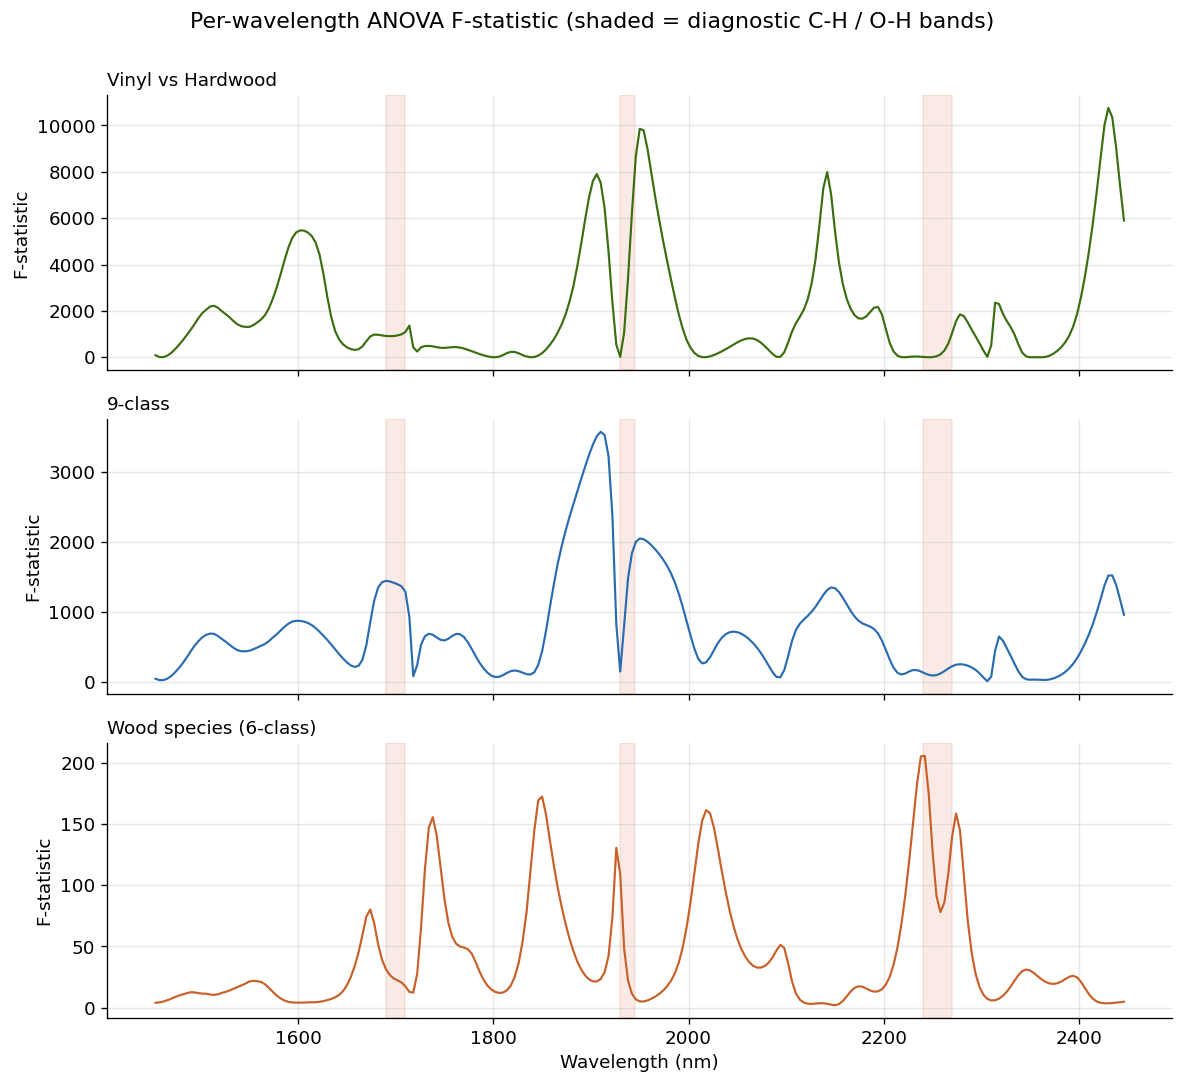

In [9]:
def shade_bands(ax):
    """Draw the three diagnostic bands as faint orange stripes on a plot."""
    for lo, hi, lbl in VIP_BANDS:
        ax.axvspan(lo, hi, color='#d85a30', alpha=0.12)

# One stacked panel per comparison: F-statistic vs wavelength = a "discrimination spectrum"
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, (F, ttl, col) in zip(axes, [
        (F_bin, 'Vinyl vs Hardwood', '#3b6d11'),
        (F_9, '9-class', '#2b6cb0'),
        (F_w, 'Wood species (6-class)', '#c8602a')]):
    ax.plot(wavelengths, F, color=col, lw=1.3)   # the F curve
    shade_bands(ax)                              # overlay diagnostic bands
    ax.set_ylabel('F-statistic')
    ax.set_title(ttl, loc='left', fontsize=11)
axes[-1].set_xlabel('Wavelength (nm)')
fig.suptitle('Per-wavelength ANOVA F-statistic (shaded = diagnostic C-H / O-H bands)', y=1.0)
fig.tight_layout()
fig.savefig('anova_fstatistic.png', bbox_inches='tight')   # save for reports
plt.show()

**Reading it:** The *Vinyl vs Hardwood* panel (top) is high almost everywhere — the materials
differ across the board. The *9-class* and *wood-species* panels are lower and spikier, with the
biggest spikes clustering in/near the shaded C–H and O–H bands — exactly where cellulose, lignin,
and the plastic's C–H bonds absorb.

## Step 7 · Picture 2 — significance map (which colours pass the honesty test?)

This is a **Manhattan plot**, borrowed from genetics. Height = `-log10(p-value)`, so **taller dots =
more statistically certain**. The dashed orange line is the strict Bonferroni cutoff:

- **Coloured dots above the line** → genuinely significant (survive the multiple-testing correction).
- **Grey dots below the line** → not significant; could be noise.

It answers "*how sure* are we?", complementing Picture 1's "*how big* is the effect?".

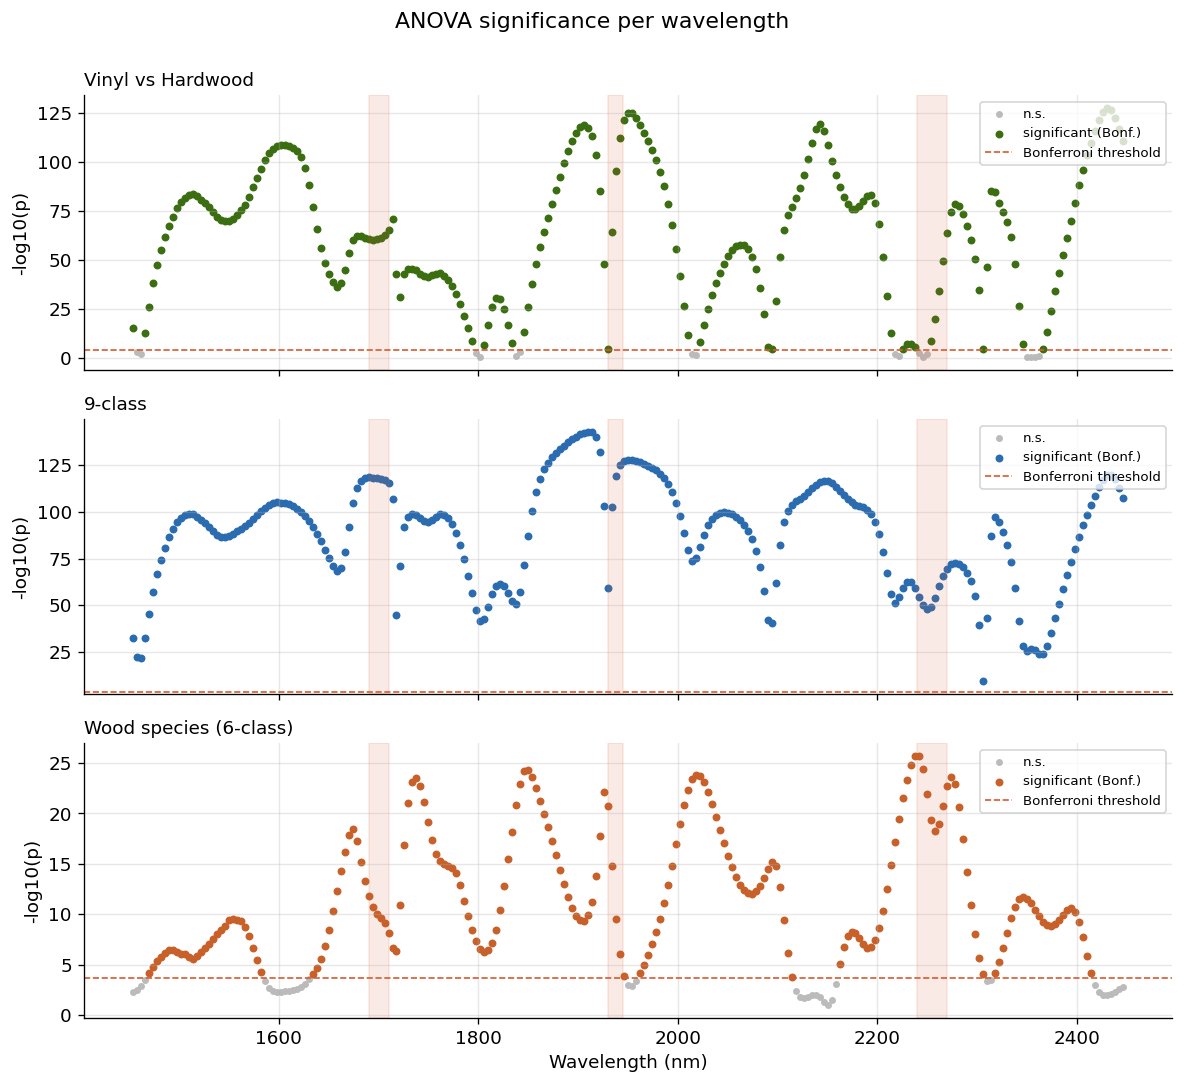

In [10]:
# Manhattan plot: statistical certainty (-log10 p) vs wavelength, per comparison
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, (P, bonf, ttl, col) in zip(axes, [
        (P_bin, bonf_bin, 'Vinyl vs Hardwood', '#3b6d11'),
        (P_9, bonf_9, '9-class', '#2b6cb0'),
        (P_w, bonf_w, 'Wood species (6-class)', '#c8602a')]):
    nlog = -np.log10(np.clip(P, 1e-300, None))   # bigger = more certain (clip avoids log(0))
    sig = P < bonf                               # which pass the Bonferroni bar
    ax.scatter(wavelengths[~sig], nlog[~sig], s=10, color='#bbb', label='n.s.')          # grey = not sig.
    ax.scatter(wavelengths[sig],  nlog[sig],  s=14, color=col,   label='significant (Bonf.)')
    ax.axhline(-np.log10(bonf), ls='--', color='#d85a30', lw=1, label='Bonferroni threshold')
    shade_bands(ax)
    ax.set_ylabel('-log10(p)')
    ax.set_title(ttl, loc='left', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
axes[-1].set_xlabel('Wavelength (nm)')
fig.suptitle('ANOVA significance per wavelength', y=1.0)
fig.tight_layout()
fig.savefig('anova_pvalues.png', bbox_inches='tight')
plt.show()

## Step 8 · Zooming in — *which pairs* does the best colour separate? (Tukey HSD)

A significant ANOVA only says "at least one group differs." It doesn't say *which*. To dig in, we
take the single most discriminating wavelength from the 9-class test and run a **Tukey HSD** post-hoc
test — it compares **every pair** of the 9 classes and flags which pairs are significantly different.

Read the table as: `group1` vs `group2`, the average gap between them (`meandiff`), and `reject =
True` meaning "these two are significantly different at this wavelength." This reveals *why*
classifiers occasionally slip: the pairs that come back **not** different are the look-alikes that
get confused.

In [11]:
# Take the most discriminating wavelength from the 9-class test...
top_wl_idx = int(np.argmax(F_9))
print(f'Most discriminating wavelength (9-class): {wavelengths[top_wl_idx]:.0f} nm (F={F_9[top_wl_idx]:.0f})')

# ...and ask Tukey HSD which of the 9*8/2 = 36 class PAIRS actually differ there
tukey = pairwise_tukeyhsd(endog=X[:, top_wl_idx], groups=y_9, alpha=ALPHA)
tuk_df = pd.DataFrame(tukey._results_table.data[1:], columns=tukey._results_table.data[0])
n_sig_pairs = int(tuk_df['reject'].sum())       # reject == True  ->  the pair is different
print(f'{n_sig_pairs}/{len(tuk_df)} class pairs differ significantly at this wavelength\n')
print(tuk_df[tuk_df['reject'] == True].head(15).to_string(index=False))   # show first 15 differing pairs

Most discriminating wavelength (9-class): 1910 nm (F=3574)


30/36 class pairs differ significantly at this wavelength

    group1         group2  meandiff  p-adj  lower  upper  reject
LVP 12 mil            fir    0.1700  0.000 0.1643 0.1757    True
LVP 12 mil       mahogany    0.1594  0.000 0.1524 0.1664    True
LVP 12 mil            oak    0.1383  0.000 0.1313 0.1453    True
LVP 12 mil particle board    0.1391  0.000 0.1315 0.1466    True
LVP 12 mil           pine    0.1602  0.000 0.1547 0.1657    True
LVP 12 mil         poplar    0.1319  0.000 0.1249 0.1389    True
LVP 22 mil      LVP 6 mil    0.0056  0.001 0.0015 0.0097    True
LVP 22 mil            fir    0.1736  0.000 0.1678 0.1794    True
LVP 22 mil       mahogany    0.1630  0.000 0.1560 0.1701    True
LVP 22 mil            oak    0.1419  0.000 0.1348 0.1490    True
LVP 22 mil particle board    0.1427  0.000 0.1350 0.1503    True
LVP 22 mil           pine    0.1638  0.000 0.1582 0.1694    True
LVP 22 mil         poplar    0.1355  0.000 0.1284 0.1426    True
 LVP 6 mil            fir    0.

**Reading it:** most of the 36 possible pairs are clearly separated (vinyl-vs-wood pairs
especially). The pairs that *don't* separate at this single wavelength tend to be chemically similar
woods — which is exactly where the SVM/LDA classifiers make their few mistakes. One wavelength can't
do everything; that's why the full models use all of them together.

## Step 9 · Does the statistics agree with the chemistry?

The pay-off. For each comparison we count how many significant wavelengths fall **inside the three
diagnostic bands**, and compare the **average F inside the bands vs overall**. If the in-band average
F is clearly higher, the bands really are doing the heavy lifting — an independent, purely
statistical confirmation of what chemists derived from molecular physics (and what the PLS model's
VIP scores flagged).

In [12]:
def in_bands(wl):
    """True if a wavelength falls inside any of the three diagnostic bands."""
    return any(lo <= wl <= hi for lo, hi, _ in VIP_BANDS)

band_mask = np.array([in_bands(w) for w in wavelengths])   # which of the 249 are "in band"

# For each comparison: how concentrated is the signal in the diagnostic bands?
rows_tbl = []
for name, F, P, bonf in [('Vinyl vs HW', F_bin, P_bin, bonf_bin),
                         ('9-class', F_9, P_9, bonf_9),
                         ('Wood (6)', F_w, P_w, bonf_w)]:
    sig = P < bonf
    rows_tbl.append({
        'Comparison': name,
        'Sig. wavelengths (Bonf.)': int(sig.sum()),                 # total significant
        'In diagnostic bands': int((sig & band_mask).sum()),        # ...and inside a band
        'Band wls significant': f'{int((sig & band_mask).sum())}/{int(band_mask.sum())}',
        'Mean F in bands': round(float(F[band_mask].mean()), 1),     # avg power inside bands
        'Mean F overall': round(float(F.mean()), 1),                 # avg power everywhere
    })
overlap = pd.DataFrame(rows_tbl)
print(overlap.to_string(index=False))

 Comparison  Sig. wavelengths (Bonf.)  In diagnostic bands Band wls significant  Mean F in bands  Mean F overall
Vinyl vs HW                       232                   15                15/18           1031.8          1971.5
    9-class                       249                   18                18/18            761.7           740.3
   Wood (6)                       209                   18                18/18             74.6            41.8


**Reading it:** for the wood-species comparison especially, the mean F *inside* the diagnostic
bands is well above the overall mean — the C–H/O–H bands are disproportionately informative, even
though they're a small slice of the spectrum.

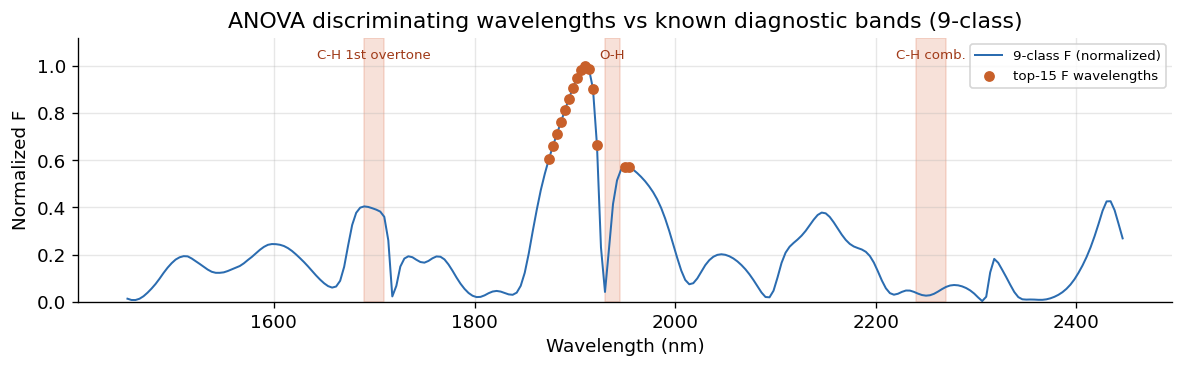

In [13]:
# Visual overlay: do the strongest 9-class wavelengths land on the known bands?
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(wavelengths, F_9 / F_9.max(), color='#2b6cb0', lw=1.2,    # F rescaled to 0-1
        label='9-class F (normalized)')
for lo, hi, lbl in VIP_BANDS:                                     # draw + label each band
    ax.axvspan(lo, hi, color='#d85a30', alpha=0.18)
    ax.text((lo + hi) / 2, 1.02, lbl, ha='center', va='bottom', fontsize=8, color='#a03a18')
topk = np.argsort(F_9)[::-1][:15]                                 # the 15 strongest wavelengths
ax.scatter(wavelengths[topk], (F_9 / F_9.max())[topk], color='#c8602a', s=30, zorder=5,
           label='top-15 F wavelengths')
ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('Normalized F')
ax.set_ylim(0, 1.12)
ax.set_title('ANOVA discriminating wavelengths vs known diagnostic bands (9-class)')
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
fig.savefig('anova_vip_rfe_comparison.png', bbox_inches='tight')
plt.show()

**Reading it:** the blue curve is the 9-class discrimination power (rescaled to 0–1). The orange
dots mark the 15 most discriminating wavelengths; notice how they pile up around the labelled C–H and
O–H bands rather than scattering randomly.

## Step 10 · So what did we learn?

**In one sentence:** the colours that statistically separate the flooring types are the same colours
chemistry says they *should* be — which means the classifiers in the other notebooks are learning
real chemistry, not coincidences.

**The details, in plain language:**

1. **Vinyl vs Hardwood is easy and obvious.** Almost every wavelength differs significantly — the
   plastic and the wood have different fingerprints across the whole spectrum. This matches the
   ~100% accuracy the PCA and SVM analyses get on this task.

2. **Telling the 9 classes (or 6 species) apart is harder and more selective.** Fewer wavelengths
   carry the signal, and the strongest ones cluster in the **C–H (~1690–1710, ~2240–2270 nm)** and
   **O–H (~1938 nm)** bands — the absorption features of cellulose, lignin, and the plastic's
   hydrocarbon chains.

3. **The look-alikes are explained.** Tukey HSD shows the class pairs that *don't* separate are
   chemically similar woods — the same pairs the classifiers occasionally confuse. The statistics
   and the model errors tell a consistent story.

4. **Independent confirmation of the important wavelengths.** ANOVA started from raw statistics with
   no chemistry input, yet it landed on the same diagnostic bands as the PLS model's VIP scores.
   When two different methods agree, we can trust the conclusion: *a cheaper instrument measuring
   just these few bands could likely do most of the job.*

**Figures saved:** `anova_fstatistic.png` (discrimination spectrum), `anova_pvalues.png`
(significance map), `anova_vip_rfe_comparison.png` (top colours vs diagnostic bands).
